In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
import random
import math
from task_sampler import task_shift, f, get_batch, get_batch_test, get_batch_val
import scipy
import matplotlib
import matplotlib.pyplot as plt


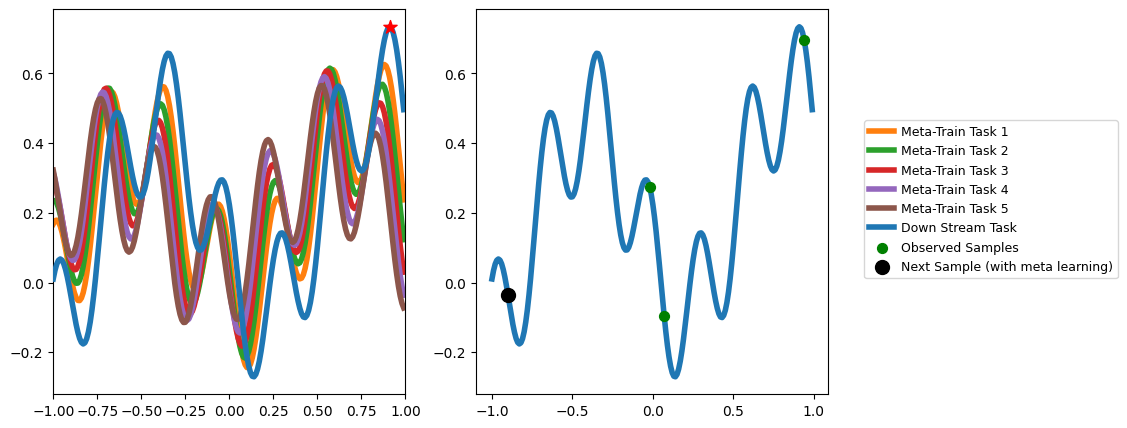

In [7]:
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)
fontsize = 18
lw=4


X_spt, y_spt, X_qry, y_qry = get_batch_test(spt_size=4, task = 8 , step=0.01)

meta_data = {}
for i, task in enumerate(range(10,15)):
    if i == 0:
        y_shifted = f(X_qry, shift=task_shift(task))
    #elif i == 1:
    #    y_shifted = 0.5*f(X_qry, shift=task_shift(20))
    else:
        y_shifted = f(X_qry, shift=task_shift(task))
    meta_data[i] = {
            "X": X_qry,
            "y": y_shifted.squeeze(-1),
        }



fig, axs = plt.subplots(1,2, figsize=(10,5))



incumbent = X_spt[y_spt.argmax()].reshape(-1)


axs[1].plot(X_qry,y_qry, linewidth=lw,label="Down Stream Task")
axs[1].scatter(X_spt[:-1], y_spt[:-1], s= 50, c= "green", label="Observed Samples", zorder = 99)



X_qry = torch.Tensor(np.arange(-1, 1, 0.01)).reshape(-1,1)
y_qry = f(X_qry, shift=task_shift(8))
axs[0].plot(X_qry, y_qry, linewidth=lw, label="\textbf{Down Stream Task}", zorder = 99)
axs[0].scatter([X_qry[y_qry.argmax()]], [y_qry.max()], marker="*", s=100, c= "red", zorder = 99)

#axs[0].scatter(X_spt[:-1], y_spt[:-1], s= 1000)

task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

for i, task in enumerate(range(10,15)):
    axs[0].plot(meta_data[i]["X"], meta_data[i]["y"], linewidth=lw, label=task_names[i])
    #axs[0].scatter(X_spt[:-1], imputed_y[:, i], s= 1000)
    
axs[1].scatter(X_spt[-1], y_spt[-1], s= 100, c= "black", label="Next Sample (with meta learning)", zorder = 99)

axs[0].set_xlim(-1,1)


lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
lines.pop(0)
labels.pop(0)

anchor = (0.93, 0, 0.5, 1)
fig.legend(lines, labels,loc="center left", bbox_to_anchor=anchor, ncol=1, fontsize=fontsize*0.5,  handletextpad=0.5, labelspacing = 0.5, columnspacing=1.)
fig.subplots_adjust(wspace=0.2)